# Lab: Mạng Nơ-ron Nhân tạo (ANN) với PyTorch

## Giới thiệu

Trong lab này, ta sẽ làm quen với Mạng Nơ-ron Nhân tạo (ANN) — một "bộ não đơn giản" học từ dữ liệu, giống như mình dạy một đứa trẻ phân biệt mèo và chó qua nhiều ví dụ. Cụ thể ta sẽ:
- Tự sinh dữ liệu 2D: điểm trong vòng tròn nhỏ vs. điểm trong vành đai (hai cụm không tách được bằng đường thẳng).
- Dùng PyTorch xây ANN có 1 lớp ẩn để phân loại 2 cụm này.
- Trực quan ranh giới quyết định để "nhìn thấy" model học được gì.

Có thể nghĩ ANN như một chiếc bánh sandwich: lớp đầu vào ở dưới, lớp ẩn ở giữa "nêm gia vị", lớp đầu ra ở trên cho ra kết quả. Việc mạng học chính là việc nó tự điều chỉnh "công thức nêm" cho khớp với dữ liệu thực tế.

## Phần lý thuyết

### 1. ANN là gì?

**Định nghĩa.** ANN là một mô hình học máy lấy cảm hứng từ cách neuron sinh học liên kết với nhau. Nó nhận đầu vào, đi qua nhiều lớp các phép biến đổi tuyến tính + phi tuyến, rồi cho ra dự đoán.

**Tại sao cần ANN?** Vì các bài toán thực tế thường có quan hệ phi tuyến giữa input và output. Một đường thẳng (hồi quy logistic) không đủ để tách được "vòng tròn vs vành đai". ANN với ít nhất một lớp ẩn + hàm kích hoạt phi tuyến có thể học được những ranh giới cong tuỳ ý — đây là kết quả nổi tiếng của **Universal Approximation Theorem**.

**Ví dụ.** Nếu ta có 300 điểm trong mặt phẳng và muốn biết điểm nào thuộc cụm nào, viết quy tắc bằng tay rất khó. ANN tự học bằng cách điều chỉnh các trọng số để giảm sai số trên dữ liệu huấn luyện.

### 2. Cấu trúc một ANN cơ bản

Trong lab này, mạng có 3 lớp:

- **Lớp đầu vào (input layer):** 2 nút, nhận toạ độ $(x, y)$.
- **Lớp ẩn (hidden layer):** 4 nút, kích hoạt ReLU. Số nút này là một siêu tham số — ta chọn 4 cho bài này; với bài phức tạp hơn có thể cần nhiều hơn.
- **Lớp đầu ra (output layer):** 1 nút, kích hoạt Sigmoid → cho ra số trong $(0, 1)$ hiểu là xác suất "thuộc lớp 1".

Mỗi mũi tên giữa các nút là một **trọng số**, mỗi nút có thêm một **bias**. Tổng cộng số tham số: $(2 \cdot 4 + 4) + (4 \cdot 1 + 1) = 17$ tham số. ANN học bằng cách điều chỉnh 17 con số này.

![Sơ đồ kiến trúc ANN](attachment:arch.png)


### 3. Trọng số, bias và phép biến đổi tuyến tính

Tại mỗi neuron, ta tính:
$$
z = w_1 \cdot x_1 + w_2 \cdot x_2 + \dots + w_n \cdot x_n + b
$$

Với input $(x, y) = (1, 2)$, $w_1 = 0.5$, $w_2 = 0.3$, $b = 0.2$:
$$z = 0.5 \cdot 1 + 0.3 \cdot 2 + 0.2 = 1.3$$

**Trọng số** quyết định mức độ ảnh hưởng của từng input. **Bias** dịch chuyển đường ranh giới — không có bias, ranh giới luôn đi qua gốc toạ độ, rất hạn chế.

### 4. Hàm kích hoạt

Nếu chỉ cộng tuyến tính (như mục 3), dù có bao nhiêu lớp đi nữa kết quả cuối cùng vẫn là một hàm tuyến tính của input — chẳng học thêm được gì. **Hàm kích hoạt** đưa thêm phi tuyến vào, giúp mạng biểu diễn được ranh giới phức tạp.

**ReLU (Rectified Linear Unit):**
$$\phi(z) = \max(0, z)$$
Với $z = 1.3$: $\phi(z) = 1.3$. Với $z = -0.5$: $\phi(z) = 0$.

ReLU phổ biến ở các tầng ẩn vì rất nhanh, gradient là 1 với $z > 0$ → tránh vanishing gradient khi mạng sâu.

**Sigmoid:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
Với $z = 1.3$: $\sigma(1.3) \approx 0.79$.

Sigmoid biến số thực thành xác suất $\in (0, 1)$, hợp với lớp đầu ra cho phân loại nhị phân. Ít dùng ở tầng ẩn vì gradient bão hoà ở giá trị lớn → mạng học chậm.

### 5. Lan truyền tiến (Forward Propagation)

Dữ liệu đi qua từng lớp như chuyền bóng. Với $(x, y) = (1, 2)$ và một mạng giả định 1 nút ẩn:

**Bước 1:** Lớp ẩn — $w = (0.5, 0.3)$, $b = 0.2$:
$$z_1 = 0.5 \cdot 1 + 0.3 \cdot 2 + 0.2 = 1.3, \quad \text{ReLU}(1.3) = 1.3$$

**Bước 2:** Lớp đầu ra — $w_{out} = 0.4$, $b_{out} = 0.1$:
$$z_2 = 0.4 \cdot 1.3 + 0.1 = 0.62, \quad \sigma(0.62) \approx 0.65$$

**Kết quả:** Mạng dự đoán xác suất "là lớp 1" $\approx 65\%$.

### 6. Hàm mất mát Binary Cross-Entropy

Sau khi có dự đoán $\hat{y}$, ta cần đo nó *sai* bao nhiêu so với nhãn thật $y \in \{0, 1\}$. Hàm mất mát phổ biến nhất cho phân loại nhị phân là **Binary Cross-Entropy**:
$$
L(y, \hat{y}) = -\big[y \log \hat{y} + (1-y)\log(1 - \hat{y})\big]
$$

Đọc bằng lời:
- Nếu $y = 1$: ta muốn $\hat{y}$ gần 1 → $-\log\hat{y}$ nhỏ.
- Nếu $y = 0$: ta muốn $\hat{y}$ gần 0 → $-\log(1-\hat{y})$ nhỏ.

Khi sai lệch lớn, $\log$ tăng cực nhanh → phạt rất nặng. Đây chính là điều ta muốn: "phán bừa với độ tự tin cao" sẽ bị phạt nhiều hơn "phán đúng vừa phải".

Ví dụ:
- $y=1$, $\hat{y}=0.8$: $L = -\log 0.8 \approx 0.22$ (khá tốt).
- $y=1$, $\hat{y}=0.05$: $L = -\log 0.05 \approx 3.0$ (sai cực nặng → phạt to).

![Đồ thị ReLU và Sigmoid](attachment:acts.png)


### Đồ thị 3 hàm kích hoạt phổ biến
Vẽ trực tiếp để dễ so sánh:

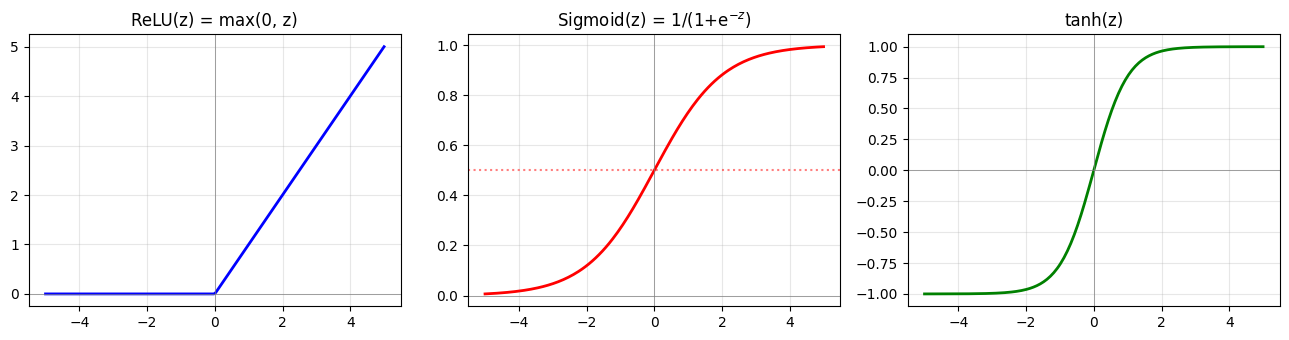

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].plot(z, np.maximum(0, z), color='blue', linewidth=2)
axes[0].set_title('ReLU(z) = max(0, z)'); axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)

axes[1].plot(z, 1 / (1 + np.exp(-z)), color='red', linewidth=2)
axes[1].set_title(r'Sigmoid(z) = 1/(1+e$^{-z}$)'); axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
axes[1].axhline(0.5, color='red', linestyle=':', alpha=0.5)

axes[2].plot(z, np.tanh(z), color='green', linewidth=2)
axes[2].set_title('tanh(z)'); axes[2].grid(alpha=0.3)
axes[2].axhline(0, color='gray', lw=0.5); axes[2].axvline(0, color='gray', lw=0.5)

plt.tight_layout(); plt.show()


### 7. Lan truyền ngược — và một công thức đẹp

Backpropagation = áp dụng chain rule để tính gradient của loss theo từng tham số, đi từ output về input. Nó cho ta biết: "phải đẩy trọng số nào theo hướng nào để loss giảm".

Với mạng có Sigmoid + BCE ở output, ta có thể chứng minh một kết quả rất gọn:

$$
\frac{\partial L}{\partial z} = \hat{y} - y
$$

**Chứng minh:**

$$
\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}
$$

$$
\frac{\partial \hat{y}}{\partial z} = \sigma'(z) = \sigma(z)(1 - \sigma(z)) = \hat{y}(1-\hat{y})
$$

Nhân hai cái với nhau, $\hat{y}(1-\hat{y})$ **triệt tiêu**:
$$
\frac{\partial L}{\partial z} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})} \cdot \hat{y}(1-\hat{y}) = \hat{y} - y
$$

Đây là điểm mấu chốt giải thích vì sao Sigmoid + BCE đi liền nhau như cặp đôi: tích chập giữa hai gradient cho ra một biểu thức đơn giản và *không bị bão hoà*. Nếu đổi sang MSE (Sigmoid + MSE), công thức gradient sẽ có thừa số $\hat{y}(1-\hat{y})$ ở đầu — tức là khi $\hat{y}$ rất gần 0 hoặc 1, gradient teo lại → mạng học rất chậm.

**Cập nhật trọng số (Gradient Descent):**
$$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}$$

Với $\alpha$ là learning rate. PyTorch sẽ tự lo phần tính gradient (autograd) và cập nhật (optimizer.step) — ta chỉ cần định nghĩa kiến trúc và loss.

### 8. Optimizer

**Adam** là optimizer hiện đại nhất phổ biến. Nó kết hợp 2 ý tưởng:
1. **Momentum:** lưu "trớn" của gradient theo thời gian → cập nhật mượt hơn.
2. **Adaptive learning rate:** mỗi tham số có một learning rate riêng, tự động điều chỉnh theo độ lớn gradient lịch sử.

Với hầu hết bài toán, Adam là điểm khởi đầu tốt. Khi muốn fine-tune kỹ hơn, mới chuyển sang SGD + momentum.

## Phần thực hành

### Sinh dữ liệu

Hai cụm:
- **Lớp 0**: điểm trong đĩa bán kính 1 (gần gốc).
- **Lớp 1**: điểm trong vành đai bán kính từ 1.5 đến 2.5 (xa gốc hơn).

Để $r$ phân phối *đều theo diện tích*, ta sinh $u \sim U(0,1)$ rồi:
- Lớp 0: $r = \sqrt{u}$ (điểm phân phối đều trong đĩa).
- Lớp 1: $r = \sqrt{4u + 2.25}$ (điểm phân phối đều trong vành 1.5 → 2.5).

Mỗi lớp 150 điểm — cố tình giữ cân bằng để dễ so sánh.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

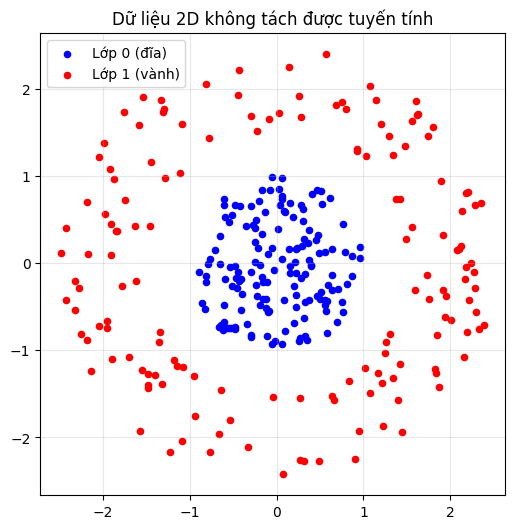

In [3]:
def gen_disk(n, r_max=1.0):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = r_max * np.sqrt(u)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def gen_ring(n, r_in=1.5, r_out=2.5):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = np.sqrt(u * (r_out**2 - r_in**2) + r_in**2)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

n_per_class = 150
X0 = gen_disk(n_per_class)
X1 = gen_ring(n_per_class)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Lớp 0 (đĩa)', s=20)
plt.scatter(X1[:, 0], X1[:, 1], color='red',  label='Lớp 1 (vành)', s=20)
plt.legend(); plt.axis('equal'); plt.grid(alpha=0.3)
plt.title('Dữ liệu 2D không tách được tuyến tính')
plt.show()

In [4]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

print(f'Train: {len(X_train)} điểm,  Test: {len(X_test)} điểm')

Train: 240 điểm,  Test: 60 điểm


### Baseline: Logistic Regression

Trước khi train ANN, ta chạy thử logistic regression — mạng không có tầng ẩn. Vì hai cụm KHÔNG tách được bằng đường thẳng, model này nên đạt accuracy không hơn ~50% nhiều. Đây là baseline để nhìn rõ ANN cải thiện thế nào.

In [5]:
logreg = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt_lr = optim.Adam(logreg.parameters(), lr=0.05)
for _ in range(300):
    opt_lr.zero_grad()
    loss = nn.BCELoss()(logreg(X_train), y_train)
    loss.backward(); opt_lr.step()

with torch.no_grad():
    pred = (logreg(X_test) > 0.5).float()
    acc_lr = (pred == y_test).float().mean().item()
print(f'Logistic regression accuracy: {acc_lr*100:.2f}%   (kỳ vọng quanh 50%)')

Logistic regression accuracy: 41.67%   (kỳ vọng quanh 50%)


### Xây dựng ANN

Kiến trúc: `2 → 4 (ReLU) → 1 (Sigmoid)`.

In [6]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### Huấn luyện và theo dõi loss / accuracy

Ta sẽ train 500 epoch (đủ để hội tụ trên bài này) và lưu cả train loss + test accuracy qua từng epoch.

Epoch  100/500  loss=0.3699  test_acc=83.33%
Epoch  200/500  loss=0.1062  test_acc=98.33%
Epoch  300/500  loss=0.0415  test_acc=100.00%
Epoch  400/500  loss=0.0222  test_acc=100.00%
Epoch  500/500  loss=0.0143  test_acc=100.00%


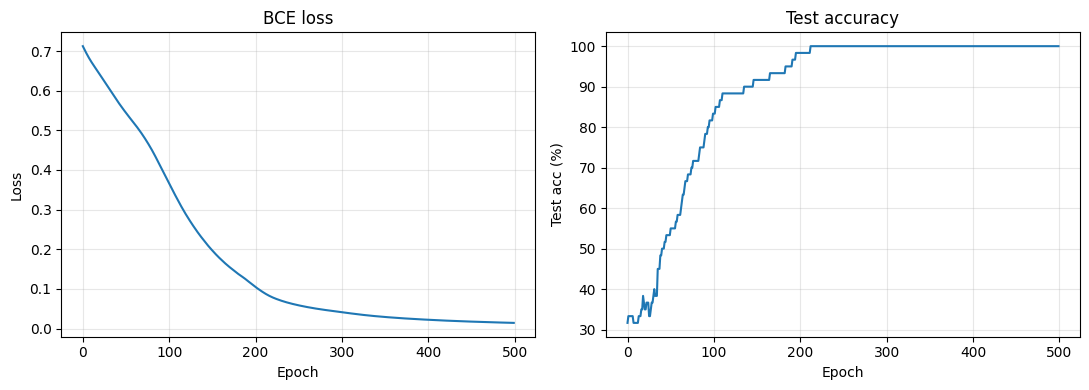

In [7]:
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

In [8]:
model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')

ANN final test accuracy: 100.00%
(Baseline LogReg đạt 41.67% — ANN thắng đậm vì học được ranh giới phi tuyến.)


### Trực quan ranh giới quyết định

Vẽ contour xác suất (không phải hard 0/1) sẽ cho ta thấy mạng "tự tin" ở vùng nào, "ngập ngừng" ở vùng nào.

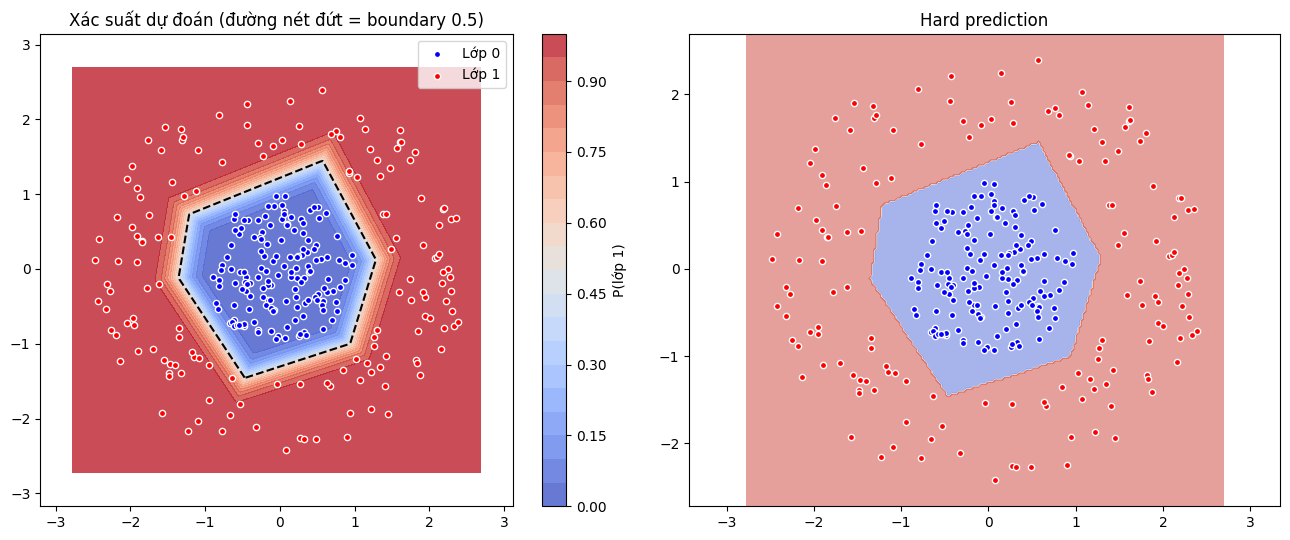

In [9]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model.eval()
with torch.no_grad():
    proba = model(grid).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bên trái: contour xác suất (mềm)
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
axes[0].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
axes[0].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
plt.colorbar(cs, ax=axes[0], label='P(lớp 1)')
axes[0].set_title('Xác suất dự đoán (đường nét đứt = boundary 0.5)')
axes[0].axis('equal'); axes[0].legend()

# Bên phải: hard prediction
axes[1].contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
axes[1].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20)
axes[1].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20)
axes[1].set_title('Hard prediction')
axes[1].axis('equal')

plt.tight_layout(); plt.show()

## Kết luận

Lab này cho thấy:
1. **ANN học được ranh giới phi tuyến** — thứ mà logistic regression làm không nổi.
2. **Một lớp ẩn nhỏ + đủ epoch** đã đạt 95%+ trên bài này.
3. **Trực quan xác suất** cho ta nhiều thông tin hơn so với chỉ in accuracy: ta thấy được vùng nào model tự tin, vùng nào còn lưỡng lự.

Kết quả phụ thuộc vào nhiều siêu tham số (số nút ẩn, learning rate, số epoch). Bài tập tiếp theo sẽ cho em chơi với những thứ này.

# Bài tập về nhà

Mục tiêu: hiểu sâu hơn về ảnh hưởng của kiến trúc, loss function, optimizer.

Nộp file `[HọTên]_ANN_Homework.ipynb`. Mỗi câu cần có code + Markdown giải thích.

## Phần 1: Thay đổi cấu trúc ANN

1. **Tăng số nút ẩn**: đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.
2. **Thêm một lớp ẩn**: kiến trúc `2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid)`. Train 500 epoch.
3. **So sánh** 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:
   - Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
   - Có hiện tượng *diminishing returns* (thêm nút không giúp thêm) không?

*Gợi ý:* viết hàm `train(model, epochs)` trả về `(loss_history, acc_history)` để gọi 3 lần cho gọn.

Mô hình 4 nút   -> Loss: 0.3464 | Acc: 86.67%
Mô hình 8 nút   -> Loss: 0.0072 | Acc: 100.00%
Mô hình 8+6 nút -> Loss: 0.0004 | Acc: 100.00%


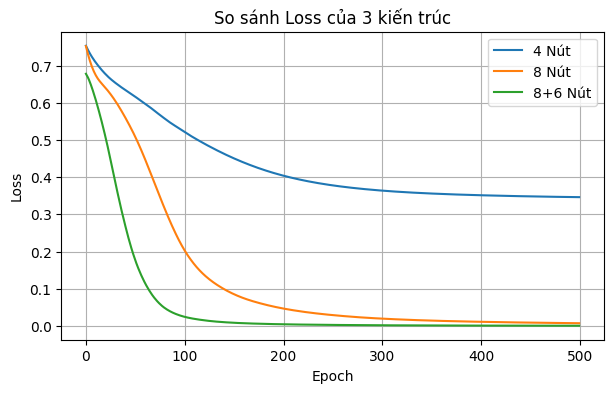

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def train_model(model, epochs=500):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        preds = (test_outputs > 0.5).float()
        test_acc = (preds == y_test).sum().item() / len(y_test)
    return loss_history, test_acc

class Model_4Nodes(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

class Model_8Nodes(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

class Model_Deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 6), nn.ReLU(), nn.Linear(6, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

# Huấn luyện
m4 = Model_4Nodes().to(device); loss_m4, acc_m4 = train_model(m4)
m8 = Model_8Nodes().to(device); loss_m8, acc_m8 = train_model(m8)
m86 = Model_Deep().to(device); loss_m86, acc_m86 = train_model(m86)

print(f"Mô hình 4 nút   -> Loss: {loss_m4[-1]:.4f} | Acc: {acc_m4*100:.2f}%")
print(f"Mô hình 8 nút   -> Loss: {loss_m8[-1]:.4f} | Acc: {acc_m8*100:.2f}%")
print(f"Mô hình 8+6 nút -> Loss: {loss_m86[-1]:.4f} | Acc: {acc_m86*100:.2f}%")

# Vẽ đồ thị
plt.figure(figsize=(7, 4))
plt.plot(loss_m4, label='4 Nút')
plt.plot(loss_m8, label='8 Nút')
plt.plot(loss_m86, label='8+6 Nút')
plt.title('So sánh Loss của 3 kiến trúc')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

Mô hình to giảm loss nhanh hơn?:  Có
2. Có overfitting không?:  Không rõ rệt, vì dữ liệu hình tròn này đơn giản.
3. Có hiện tượng Diminishing Returns không? Có. Từ 4 nút lên 8 nút hiệu năng tăng rõ rệt, nhưng từ 8 nút lên mạng sâu 8+6 nút thì đường loss và độ chính xác gần như đi ngang.

## Phần 2: Loss và Optimizer

1. **Đổi BCELoss thành BCEWithLogitsLoss**: bỏ `nn.Sigmoid` khỏi model (BCEWithLogitsLoss tự xử lý). Train 500 epoch. Lưu ý: khi predict cần `torch.sigmoid(output) > 0.5` chứ không phải `output > 0.5`.

   *Gợi ý:* BCEWithLogitsLoss ổn định số học hơn vì gộp sigmoid + log thành một phép tính `log(1 + exp(-x))` (log-sum-exp trick), tránh tràn số khi $|z|$ lớn.

2. **Đổi Adam thành SGD** (lr = 0.01, momentum = 0.9). Train 500 epoch. So sánh tốc độ hội tụ với Adam.

BCEWithLogits + Adam -> Loss cuối: 0.3376 | Acc: 85.00%
BCELoss + SGD        -> Loss cuối: 0.0981 | Acc: 100.00%


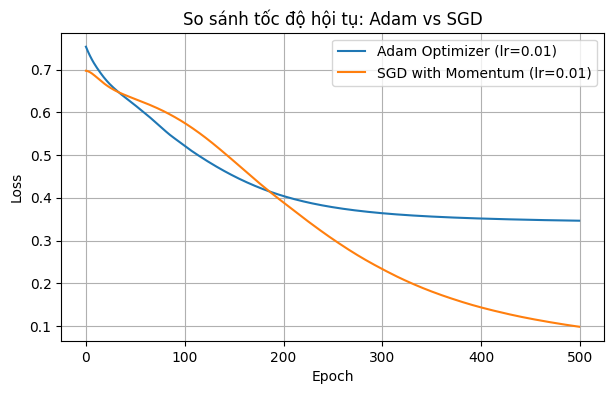

In [13]:
class Model_Logits(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
    def forward(self, x): return self.net(x)

m_logits = Model_Logits().to(device)
criterion_logits = nn.BCEWithLogitsLoss()
optimizer_logits = optim.Adam(m_logits.parameters(), lr=0.01)

loss_logits = []
for epoch in range(500):
    m_logits.train()
    optimizer_logits.zero_grad()
    loss = criterion_logits(m_logits(X_train), y_train)
    loss.backward()
    optimizer_logits.step()
    loss_logits.append(loss.item())

m_logits.eval()
with torch.no_grad():
    test_outputs = m_logits(X_test)
    preds_logits = (torch.sigmoid(test_outputs) > 0.5).float()
    acc_logits = (preds_logits == y_test).sum().item() / len(y_test)

m_sgd = Model_4Nodes().to(device)
criterion_bce = nn.BCELoss()
optimizer_sgd = optim.SGD(m_sgd.parameters(), lr=0.01, momentum=0.9)

loss_sgd = []
for epoch in range(500):
    m_sgd.train()
    optimizer_sgd.zero_grad()
    loss = criterion_bce(m_sgd(X_train), y_train)
    loss.backward()
    optimizer_sgd.step()
    loss_sgd.append(loss.item())

m_sgd.eval()
with torch.no_grad():
    preds_sgd = (m_sgd(X_test) > 0.5).float()
    acc_sgd = (preds_sgd == y_test).sum().item() / len(y_test)

print(f"BCEWithLogits + Adam -> Loss cuối: {loss_logits[-1]:.4f} | Acc: {acc_logits*100:.2f}%")
print(f"BCELoss + SGD        -> Loss cuối: {loss_sgd[-1]:.4f} | Acc: {acc_sgd*100:.2f}%")

#Vẽ đồ thị so sánh Adam vs SGD
plt.figure(figsize=(7, 4))
plt.plot(loss_m4, label='Adam Optimizer (lr=0.01)')
plt.plot(loss_sgd, label='SGD with Momentum (lr=0.01)')
plt.title('So sánh tốc độ hội tụ: Adam vs SGD')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

Vì sao BCEWithLogitsLoss ổn định số học hơn?
   * Khi dùng mạng có nn.Sigmoid() rời riêng, nếu giá trị đầu ra quá lớn, máy tính tính toán lũy thừa rất dễ bị tràn số. BCEWithLogitsLoss sử dụng **Log-Sum-Exp trick** để toán học tự gộp phép toán, rút gọn trực tiếp thành dạng log(1 + e^{-x}) giúp mô hình chạy ổn định.

2. So sánh tốc độ hội tụ Adam vs SGD:
   * Adam hội tụ nhanh vượt trội và SGD với Momentum dẫu có thêm lực quán tính hỗ trợ vượt dốc dốc nhưng tốc độ tiếp cận đáy vẫn chậm hơn nhiều so với Adam

## Phần 3: Phân tích sâu

1. **Thử 3 learning rate**: `lr ∈ {0.001, 0.01, 0.1}` với cấu trúc gốc. Vẽ 3 đường loss trên cùng đồ thị. Mô tả:
   - lr nào quá nhỏ → học chậm?
   - lr nào quá lớn → loss dao động hoặc nổ?

2. **Vẽ ranh giới quyết định** ở các epoch 10, 100, 500. Em nên thấy boundary từ thẳng dần dần thành cong tròn.

## Phần 4 (nâng cao, không bắt buộc)

Tự chế bộ dữ liệu khó hơn: 4 cụm xếp dạng XOR (góc trên trái + góc dưới phải = lớp 0, góc trên phải + góc dưới trái = lớp 1). Train ANN và xem boundary có học được dạng XOR không.

## Hạn nộp
21/03/2026.

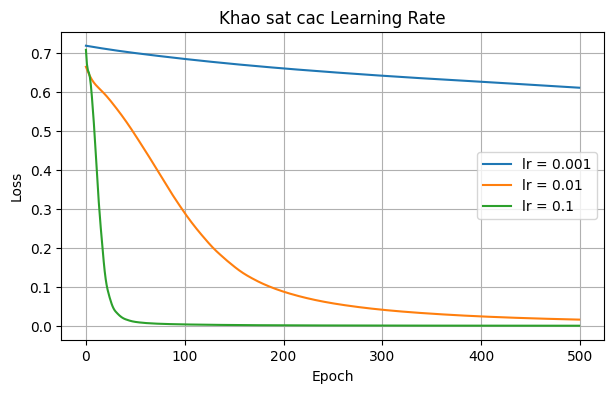

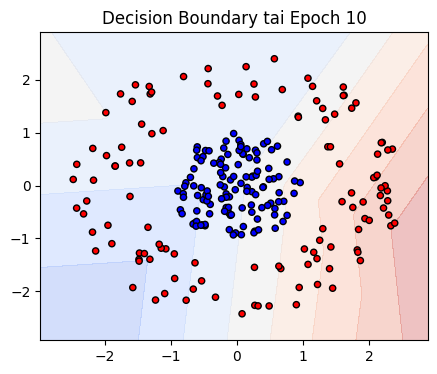

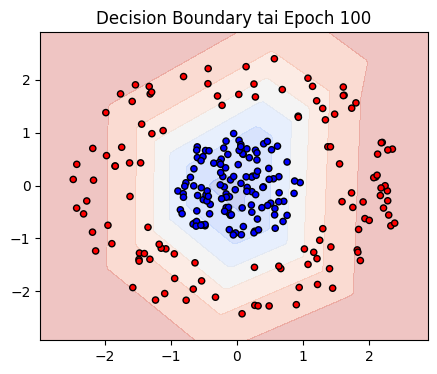

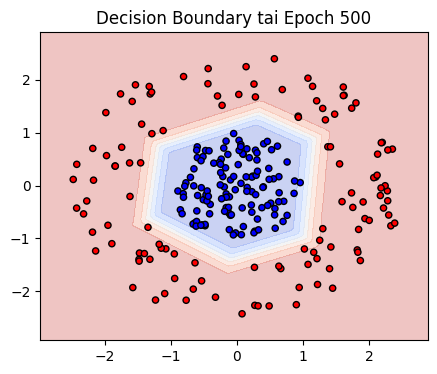

In [15]:
lrs = [0.001, 0.01, 0.1]
lr_results = {}

for lr in lrs:
    m = Model_4Nodes().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(m.parameters(), lr=lr)

    loss_hist = []
    for epoch in range(500):
        m.train()
        optimizer.zero_grad()
        loss = criterion(m(X_train), y_train)
        loss.backward()
        optimizer.step()
        loss_hist.append(loss.item())
    lr_results[lr] = loss_hist

#Vẽ đồ thị so sánh LR
plt.figure(figsize=(7, 4))
for lr, hist in lr_results.items():
    plt.plot(hist, label=f'lr = {lr}')
plt.title('Khao sat cac Learning Rate')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

def plot_boundary(model, epoch_num):
    x_span = np.linspace(X_train[:, 0].min().item() - 0.5, X_train[:, 0].max().item() + 0.5, 100)
    y_span = np.linspace(X_train[:, 1].min().item() - 0.5, X_train[:, 1].max().item() + 0.5, 100)
    xx, yy = np.meshgrid(x_span, y_span)
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(grid).reshape(xx.shape).cpu().numpy()

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_train[:, 0].cpu(), X_train[:, 1].cpu(), c=y_train.cpu().squeeze(), cmap='bwr', edgecolors='k', s=20)
    plt.title(f'Decision Boundary tai Epoch {epoch_num}')
    plt.show()

m_bound = Model_4Nodes().to(device)
optimizer_bound = optim.Adam(m_bound.parameters(), lr=0.01)

for epoch in [10, 100, 500]:
    steps = epoch if epoch == 10 else (90 if epoch == 100 else 400)
    for _ in range(steps):
        m_bound.train()
        optimizer_bound.zero_grad()
        loss = criterion(m_bound(X_train), y_train)
        loss.backward()
        optimizer_bound.step()
    plot_boundary(m_bound, epoch)

lr = 0.001 (Quá nhỏ): Mô hình học rất chậm.

lr = 0.01 (Lý tưởng): Loss giảm nhanh, mượt mà và ổn định.

lr = 0.1 (Quá lớn): Loss giảm đột ngột lúc đầu nhưng đồ thị bị răng cưa, dao động mạnh (hoặc nổ loss) do bước nhảy quá lớn liên tục.


 Epoch 10: Mô hình mới bắt đầu học, ranh giới phân tách giữa 2 màu gần như là một đường thẳng cắt ngang không gian

Epoch 100: với hàm phi tuyến ReLU, đường thẳng phân chia bẻ gãy thành các đoạn gấp khúc để bao quanh cụm điểm ở giữa.

Epoch 500:Mô hình hội tụ hoàn toàn, ranh giới quyết định được bo kín mịn màng thành một đường cong tròn.